In [ ]:
# 🛒📦 Project 2: Retail Customers, Many Orders, and Their Shipments
# 项目二：零售客户、多笔订单、以及它们的物流运单

customers (1 row per customer)  ──1 : many──▶  orders (many per customer)  ──1 : many──▶  shipments (1–2 parcels per order)
客户表（每人一行）                                订单表（每人多笔）                              运单表（每单 1–2 个包裹）
                                                  │
                                    products (price, cost) ◀── product_id            returns ◀── order_id (some orders)
```

**Role 角色:** data analyst at a retail company that sells snacks, drinks and household goods to shops and online customers, and ships them with 4 carriers.
零售公司的数据分析师，卖零食、饮料、家居用品给商店和网购客户，用 4 家承运商送货。

**Management questions 管理层的问题:**
1. Who are our **best customers**, and how many customers give us most of the revenue? 谁是**最好的客户**？多少客户贡献了大部分收入？
2. Which **segment / city / category** makes the most **profit** (not just sales)? 哪个**客群 / 城市 / 品类**的**利润**最高？
3. Which customers are **returning** goods too often? 哪些客户**退货**太频繁？
4. Are **late deliveries** hurting certain customers or cities? **延迟送达**是否影响了某些客户或城市？
5. Are there **data-quality traps** we must fix before trusting the numbers? 在相信数字之前，有没有**数据质量陷阱**要先修？

**New things you will learn 新学的东西:**
- One-to-many joins: why rows multiply, and `validate=` to protect yourself 一对多连接：行数为什么变多，以及用 `validate=` 保护自己
- Finding **duplicate keys** before joining 连接前先找**重复的钥匙**
- `nunique`, `first`, `last`, `size` in aggregation 汇总里的 `nunique`、`first`、`last`、`size`
- `transform()` — put a group total on **every row** (% of customer total) `transform()` —— 把组合计放到**每一行**
- `groupby().cumsum()` — running total **per group** 每组各自的累计
- `qcut` — split customers into equal-size groups (top 20%) `qcut` —— 把客户切成等份（前 20%）
- **RFM** customer scoring (Recency, Frequency, Monetary) **RFM** 客户评分
- Aggregate to the **right level** before joining (shipments → orders → customers) 连接前先汇总到**正确的层级**

Run cells with **Shift + Enter**. ✏️ = your turn (answer hidden under ▶️). 📝 = write your insight.

## Step 1 — Load all 6 tables 第一步：读取全部 6 张表

📒 With many tables, load them all first and print the **shape** of each. The shapes tell you the relationship: 403 customers but 6,000 orders → many orders per customer.
📒 表多的时候，先全部读进来，打印每张表的 **shape**。行数告诉你它们的关系：403 个客户但 6,000 笔订单 → 每个客户多笔订单。

In [3]:
import pandas as pd
import os

# 📒 Find the data folder automatically  自动找到 data 文件夹
# This notebook is inside "Project - Data Aggregation (Logistics)", and the Project 2 data
# is in the sub-folder "Project 2 - Retail Customers and Logistics/data". We check both places.
# 这本笔记在 "Project - Data Aggregation (Logistics)" 里，项目二的数据在子文件夹里。两个地方都检查。
DATA = './data/'
if not os.path.exists(DATA + 'customers.csv'):
    DATA = './Project 2 - Retail Customers and Logistics/data/'
#print("Reading data from 读取数据自:", os.path.abspath(DATA))

customers = pd.read_csv(DATA + 'customers.csv')
products  = pd.read_csv(DATA + 'products.csv')
orders    = pd.read_csv(DATA + 'orders.csv')
returns   = pd.read_csv(DATA + 'returns.csv')
shipments = pd.read_csv(DATA + 'shipments.csv')
carriers  = pd.read_csv(DATA + 'carriers.csv')

for name, t in [('customers', customers), ('products', products), ('orders', orders),
                ('returns', returns), ('shipments', shipments), ('carriers', carriers)]:
    print(f"{name:10s} {t.shape}")

customers  (403, 5)
products   (30, 4)
orders     (6000, 8)
returns    (240, 3)
shipments  (6463, 6)
carriers   (4, 3)


In [2]:
orders.head()

,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel
0,O204596,2025-01-01,C1041,P016,3,23.47,0.00,Web
1,O201233,2025-01-01,C1103,P017,4,39.66,0.00,Store
2,O203695,2025-01-01,C1224,P025,28,2.16,0.15,Phone
3,O200726,2025-01-01,C1278,P009,4,21.66,0.00,Web
4,O203582,2025-01-01,C1065,P030,2,27.27,0.00,Store


In [4]:
customers.head()

,customer_id,customer_name,segment,city,join_date
0,C1000,Customer 1000,Wholesale,Singapore,2024-03-09
1,C1001,Customer 1001,Online,Batam,2024-11-29
2,C1002,Customer 1002,Online,Singapore,2024-02-26
3,C1003,Customer 1003,Retail,Johor Bahru,2023-04-20
4,C1004,Customer 1004,Retail,Singapore,2024-10-05


In [5]:
shipments.head()

,shipment_id,order_id,carrier,parcel_no,delivery_days,ship_cost
0,S300000,O204596,SwiftGo,1,1,6.79
1,S300001,O201233,SwiftGo,1,3,7.22
2,S300002,O203695,BlueLine,1,4,20.01
3,S300003,O200726,BlueLine,1,4,5.99
4,S300004,O203582,SwiftGo,1,1,7.42


## Step 2 — Data-quality checks BEFORE joining 第二步：连接之前先做数据质量检查

📒 **WHAT:** check that the key is unique on the "one" side, and every key on the "many" side exists on the "one" side.
📒 **WHY:** if `customer_id` appears twice in `customers`, every order of that customer is **doubled** after the join → revenue doubled → wrong report. This is the #1 join mistake in real life.
📒 **WHEN:** every single time, before every join. 30 seconds now saves hours later.

📒 **是什么：** 检查"一"那边的钥匙是唯一的，而且"多"那边的每个钥匙在"一"那边都存在。
📒 **为什么：** 如果 `customer_id` 在 `customers` 里出现两次，这个客户的每笔订单在连接后会**变成两行** → 收入翻倍 → 报表错误。这是现实中第一常见的连接错误。
📒 **什么时候：** 每一次连接之前都要做。现在花 30 秒，以后省几小时。

In [6]:
# 2a. Is customer_id unique in the customers table?  customers 表的 customer_id 唯一吗？
print("Rows 行数            :", len(customers))
print("Unique ids 唯一 id    :", customers['customer_id'].nunique())
print("Duplicated rows 重复行:", customers['customer_id'].duplicated().sum())

# Show the duplicates  显示重复的
customers[customers['customer_id'].duplicated(keep=False)].sort_values('customer_id')

Rows 行数            : 403
Unique ids 唯一 id    : 400
Duplicated rows 重复行: 3


,customer_id,customer_name,segment,city,join_date
125,C1125,Customer 1125,Retail,Johor Bahru,2024-05-06
401,C1125,Customer 1125,Retail,Singapore,2024-05-06
328,C1328,Customer 1328,Retail,Singapore,2024-05-24
402,C1328,Customer 1328,Retail,Singapore,2024-05-24
398,C1398,Customer 1398,Online,Kuala Lumpur,2023-10-30
400,C1398,Customer 1398,Online,Singapore,2023-10-30


📒 `duplicated()` marks the 2nd, 3rd… copy as True. `keep=False` marks **all** copies → good for looking. `nunique()` = number of different values.
📒 `duplicated()` 把第 2、第 3 份标成 True。`keep=False` 把**所有**份都标出来 → 方便查看。`nunique()` = 不同值的个数。

Same customer, two rows, different city. A real company would ask the CRM team which is right. Here we keep the **first** row.
同一个客户两行，城市不同。真实公司会问 CRM 团队哪个才对。这里我们保留**第一**行。

In [7]:
# 2b. Fix: keep the first row per customer_id  修复：每个 customer_id 保留第一行
customers = customers.drop_duplicates(subset='customer_id', keep='first').reset_index(drop=True)
print("After fix 修复后:", customers.shape, "| unique:", customers['customer_id'].nunique())

After fix 修复后: (400, 5) | unique: 400


In [8]:
# 2c. Does every order's customer exist in the customers table?  每笔订单的客户都在客户表里吗？
missing_cust = ~orders['customer_id'].isin(customers['customer_id'])
print("Orders with unknown customer 客户不明的订单:", missing_cust.sum())
orders[missing_cust]['customer_id'].value_counts()

Orders with unknown customer 客户不明的订单: 12


customer_id
C9999    12
Name: count, dtype: int64

📒 `isin()` → True if the value is in the list. `~` means NOT. So `~isin` = "not in the customer table".
📒 `isin()` → 值在清单里就是 True。`~` 是"不"。所以 `~isin` = "不在客户表里"。

`C9999` has 12 orders but no customer record. We will keep those orders (revenue is real) but they will show `NaN` for segment/city after a **left** join. Now you know why left join, not inner!
`C9999` 有 12 笔订单但没有客户资料。我们保留这些订单（收入是真的），但**左**连接后它们的 segment/city 会是 `NaN`。现在你知道为什么用左连接而不是内连接了！

In [9]:
# 2d. Same check for products and the shipments -> orders link  对产品表和 运单→订单 做同样检查
print("product_id unique in products?      ", products['product_id'].is_unique)
print("order_id unique in orders?          ", orders['order_id'].is_unique)
print("order_id unique in shipments?       ", shipments['order_id'].is_unique, " <- False = some orders have 2 parcels 有些订单 2 个包裹")
print("orders with 2+ parcels 2个以上包裹的订单:", shipments['order_id'].duplicated().sum())
print("order_id unique in returns?         ", returns['order_id'].is_unique)

product_id unique in products?       True
order_id unique in orders?           True
order_id unique in shipments?        False  <- False = some orders have 2 parcels 有些订单 2 个包裹
orders with 2+ parcels 2个以上包裹的订单: 463
order_id unique in returns?          True


📒 **The map of relationships 关系地图** (write this down before joining 连接前先写下来):

| Left 左 | Right 右 | Key 钥匙 | Relationship 关系 | Safe join 安全的连接 |
|---|---|---|---|---|
| orders | customers | customer_id | many : 1 | left, `validate='m:1'` |
| orders | products | product_id | many : 1 | left, `validate='m:1'` |
| orders | returns | order_id | 1 : 1 (or 1 : 0) | left, `validate='1:1'` |
| orders | shipments | order_id | 1 : many ⚠️ | **aggregate shipments first**, then left `validate='1:1'` 先汇总运单，再连接 |

⚠️ The last row is the trap. If you join orders to shipments directly, orders with 2 parcels appear **twice** → quantity and revenue double-counted. Rule: **aggregate the "many" side up to the level you need, then join.**
⚠️ 最后一行是陷阱。如果直接把订单连到运单，有 2 个包裹的订单会出现**两次** → 数量和收入重复计算。规则：**先把"多"的那边汇总到你需要的层级，再连接。**

## Step 3 — Build the order-level table 第三步：建立订单层级的表

📒 We build one clean table `df` where **one row = one order line**, with customer, product, return and shipping info attached. All later analysis uses `df`.
📒 我们建一张干净的表 `df`，**一行 = 一笔订单**，带上客户、产品、退货和物流资料。后面的分析都用 `df`。

`validate='m:1'` makes pandas **check** the relationship and throw an error if the right side has duplicate keys. Free insurance.
`validate='m:1'` 让 pandas **检查**关系，如果右边钥匙重复就报错。免费的保险。

In [10]:
# 3a. orders + customers (many:1), left join keeps unknown customer C9999
df = pd.merge(orders, customers, on='customer_id', how='left', validate='m:1')

# 3b. + products (many:1)
df = pd.merge(df, products, on='product_id', how='left', validate='m:1', suffixes=('', '_list'))
print(df.shape)
df.head(3)

(6000, 15)


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel,customer_name,segment,city,join_date,category,unit_price_list,unit_cost
0,O204596,2025-01-01,C1041,P016,3,23.47,0.00,Web,Customer 1041,Online,Singapore,2023-04-08,Beverage,23.47,15.71
1,O201233,2025-01-01,C1103,P017,4,39.66,0.00,Store,Customer 1103,Retail,Singapore,2023-05-22,Snack,39.66,20.90
2,O203695,2025-01-01,C1224,P025,28,2.16,0.15,Phone,Customer 1224,Wholesale,Kuala Lumpur,2024-11-01,Stationery,2.16,1.44


📒 `suffixes=('', '_list')`: both tables have `unit_price`. The order's price keeps its name; the product list price becomes `unit_price_list`. Without this you get confusing `_x` / `_y`.
📒 `suffixes=('', '_list')`：两张表都有 `unit_price`。订单的价格保持原名；产品目录价变成 `unit_price_list`。不写的话会得到难懂的 `_x` / `_y`。

In [11]:
# 3c. Money columns  金额列
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.strftime('%Y-%m')
df['revenue'] = (df['quantity'] * df['unit_price'] * (1 - df['discount'])).round(2)
df['cost']    = (df['quantity'] * df['unit_cost']).round(2)
df['profit']  = (df['revenue'] - df['cost']).round(2)

df[['order_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit']].head()

,order_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,O204596,C1041,3,23.47,0.00,70.41,47.13,23.28
1,O201233,C1103,4,39.66,0.00,158.64,83.60,75.04
2,O203695,C1224,28,2.16,0.15,51.41,40.32,11.09
3,O200726,C1278,4,21.66,0.00,86.64,50.12,36.52
4,O203582,C1065,2,27.27,0.00,54.54,29.20,25.34


In [12]:
# 3d. + returns (1:1 or none). After the join, a NaN return_date means "not returned".
#     加退货（一对一或没有）。连接后 return_date 是 NaN = 没退货
df = pd.merge(df, returns, on='order_id', how='left', validate='1:1')
df['is_returned'] = df['return_date'].notna().astype(int)
print("Return rate 退货率:", round(df['is_returned'].mean(), 3))

Return rate 退货率: 0.04


📒 **The one-to-many trap, shown live 现场演示一对多陷阱**

Let's do it the WRONG way first so you see the damage. 先故意做错，让你看到后果。

In [13]:
# WRONG: join orders directly to shipments  错误：订单直接连运单
wrong = pd.merge(df, shipments, on='order_id', how='left')
print("Rows before 之前:", len(df), "| rows after 之后:", len(wrong), " <- rows multiplied! 行数变多了！")
print("Revenue before 之前:", round(df['revenue'].sum(), 2))
print("Revenue after  之后:", round(wrong['revenue'].sum(), 2), " <- double-counted 重复计算")

Rows before 之前: 6000 | rows after 之后: 6463  <- rows multiplied! 行数变多了！
Revenue before 之前: 747738.58
Revenue after  之后: 811352.11  <- double-counted 重复计算


In [14]:
# RIGHT: aggregate shipments to ONE row per order first  正确：先把运单汇总成每单一行
ship_per_order = shipments.merge(carriers, on='carrier', how='left', validate='m:1')
ship_per_order['is_late'] = (ship_per_order['delivery_days'] > ship_per_order['promised_days']).astype(int)

ship_agg = ship_per_order.groupby('order_id').agg(
    parcels=('shipment_id', 'count'),
    carrier=('carrier', 'first'),            # main carrier = first parcel's carrier  主承运商 = 第一个包裹的
    ship_cost=('ship_cost', 'sum'),          # total shipping cost of the order  订单总运费
    max_delivery_days=('delivery_days', 'max'),  # order arrives when the LAST parcel arrives  最后一个包裹到才算到
    any_late=('is_late', 'max'),             # late if ANY parcel is late  任何一个包裹迟到就算迟
).reset_index()

print("ship_agg unique order_id?", ship_agg['order_id'].is_unique)
ship_agg.head()

ship_agg unique order_id? True


,order_id,parcels,carrier,ship_cost,max_delivery_days,any_late
0,O200000,1,AsiaCargo,5.05,4,0
1,O200001,1,SwiftGo,7.18,1,0
2,O200002,1,BlueLine,6.30,5,1
3,O200003,1,AsiaCargo,7.43,6,1
4,O200004,1,SwiftGo,6.01,3,1


📒 Notice the **business logic inside the aggregation 汇总里面的业务逻辑**:
- `max` of delivery days → the customer only has the full order when the **last** parcel arrives. `max` → 客户要等**最后**一个包裹到才算收到整单。
- `max` of is_late → 1 if **any** parcel is late. `max` → **任何一个**包裹迟到就是 1。
- `sum` of ship cost → total cost of the order. `sum` → 订单总运费。
- `first` of carrier → a simple choice for a label. `first` → 用作标签的简单选择。

Choosing sum / max / first is **the analyst's decision**, not pandas'. 选 sum / max / first 是**分析师的决定**，不是 pandas 的。

In [15]:
# Now the join is 1:1 and safe  现在连接是一对一，安全了
df = pd.merge(df, ship_agg, on='order_id', how='left', validate='1:1')
print("Rows 行数:", len(df), "| Revenue 收入:", round(df['revenue'].sum(), 2), " <- unchanged 没变 ✅")
df.head(3)

Rows 行数: 6000 | Revenue 收入: 747738.58  <- unchanged 没变 ✅


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel,customer_name,segment,...,cost,profit,return_date,reason,is_returned,parcels,carrier,ship_cost,max_delivery_days,any_late
0,O204596,2025-01-01,C1041,P016,3,23.47,0.00,Web,Customer 1041,Online,...,47.13,23.28,NaN,NaN,0,1,SwiftGo,6.79,1,0
1,O201233,2025-01-01,C1103,P017,4,39.66,0.00,Store,Customer 1103,Retail,...,83.60,75.04,NaN,NaN,0,1,SwiftGo,7.22,3,1
2,O203695,2025-01-01,C1224,P025,28,2.16,0.15,Phone,Customer 1224,Wholesale,...,40.32,11.09,NaN,NaN,0,1,BlueLine,20.01,4,0


## Step 4 — From orders to customers: aggregate UP 第四步：从订单到客户：向上汇总

📒 **WHAT:** `groupby('customer_id')` turns 6,000 order rows into ~380 customer rows.
📒 **WHY:** "best customer", "repeat customer", "return-heavy customer" are all **customer-level** questions.
📒 **WHEN:** whenever the question is about the "one" side of a one-to-many.

📒 **是什么：** `groupby('customer_id')` 把 6,000 行订单变成约 380 行客户。
📒 **为什么：** "最好的客户"、"回头客"、"爱退货的客户"都是**客户层级**的问题。
📒 **什么时候：** 问题是关于一对多里"一"的那边时。

New aggregation words 新的汇总函数: `nunique` (how many different 多少个不同的), `first` / `last` (earliest / latest row 最早/最晚), `size` (rows incl. NaN 行数含 NaN).

In [16]:
cust = df.groupby('customer_id').agg(
    segment=('segment', 'first'),
    city=('city', 'first'),
    orders=('order_id', 'nunique'),           # how many orders  多少笔订单
    products_bought=('product_id', 'nunique'),# how many different products  多少种产品
    categories=('category', 'nunique'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum'),
    avg_order_value=('revenue', 'mean'),
    returns=('is_returned', 'sum'),
    late_deliveries=('any_late', 'sum'),
)
cust[['revenue', 'profit', 'avg_order_value']] = cust[['revenue', 'profit', 'avg_order_value']].round(2)

cust['return_rate'] = (cust['returns'] / cust['orders']).round(3)
cust['late_rate']   = (cust['late_deliveries'] / cust['orders']).round(3)
cust['margin_pct']  = (cust['profit'] / cust['revenue']).round(3)

print(cust.shape)
cust.sort_values('revenue', ascending=False).head(10)

(381, 15)


,segment,city,orders,products_bought,categories,first_order,last_order,revenue,profit,avg_order_value,returns,late_deliveries,return_rate,late_rate,margin_pct
customer_id,,,,,,,,,,,,,,,
C1226,Wholesale,Penang,100,29,5,2025-01-03,2025-12-31,63207.38,17221.47,632.07,0,48,0.000,0.480,0.272
C1085,Wholesale,Singapore,40,22,5,2025-01-10,2025-12-17,29461.92,8704.81,736.55,1,19,0.025,0.475,0.295
C1124,Wholesale,Johor Bahru,35,21,5,2025-01-03,2025-12-26,23311.45,6675.87,666.04,1,21,0.029,0.600,0.286
C1154,Wholesale,Singapore,31,22,4,2025-01-07,2025-12-20,17604.17,5076.60,567.88,3,14,0.097,0.452,0.288
C1364,Wholesale,Singapore,20,13,5,2025-02-19,2025-12-29,15669.24,5128.54,783.46,2,11,0.100,0.550,0.327
C1227,Wholesale,Singapore,24,19,5,2025-01-27,2025-12-13,15038.56,3884.39,626.61,0,11,0.000,0.458,0.258
C1313,Wholesale,Kuala Lumpur,22,19,5,2025-01-05,2025-12-30,14806.36,4594.66,673.02,0,10,0.000,0.455,0.310
C1152,Wholesale,Singapore,23,13,5,2025-01-01,2025-12-16,14679.03,4298.19,638.22,1,14,0.043,0.609,0.293
C1224,Wholesale,Kuala Lumpur,25,17,5,2025-01-01,2025-12-21,14239.77,4238.33,569.59,0,13,0.000,0.520,0.298


📒 Compare `orders` vs `products_bought`: a customer with 40 orders but 3 products is a **loyal repeat buyer of few items**; 40 orders and 25 products is a **browser**. Different marketing!
📒 比较 `orders` 和 `products_bought`：40 笔订单只买 3 种产品是**少数商品的忠实回头客**；40 笔订单买 25 种是**到处逛的客户**。营销方式不同！

✏️ **Your turn 轮到你:** How many customers placed only **1** order (one-time buyers)? 有多少客户只下过 **1** 笔订单？

<details><summary>▶️ Answer 答案</summary>

```python
(cust['orders'] == 1).sum()
# or as % of customers  或者占客户的百分比
(cust['orders'] == 1).mean().round(3)
```
</details>

In [17]:
# Write your code here  在这里写代码
(cust['orders'] == 1).sum()
(cust['orders'] == 1).mean().round(3)

np.float64(0.073)

## Step 5 — Who matters most? Pareto with `cumsum` + `qcut` 第五步：谁最重要？帕累托 + 分组

📒 **WHAT:** sort customers by revenue, running total, % of total → "top X customers = Y% of revenue".
📒 **WHY:** the classic 80/20 question every manager asks. **WHEN:** any "concentration" question — customers, products, suppliers, overdue invoices.

📒 **是什么：** 按收入排序客户，累计，占比 → "前 X 个客户 = Y% 的收入"。
📒 **为什么：** 每个经理都会问的经典 80/20 问题。**什么时候：** 任何"集中度"问题 —— 客户、产品、供应商、逾期发票。

In [18]:
pareto = cust.sort_values('revenue', ascending=False)[['segment', 'revenue']].copy()
pareto['cum_revenue'] = pareto['revenue'].cumsum()
pareto['cum_pct']     = (pareto['cum_revenue'] / pareto['revenue'].sum()).round(3)
pareto['rank']        = range(1, len(pareto) + 1)
pareto['cust_pct']    = (pareto['rank'] / len(pareto)).round(3)

# How many customers make 80% of revenue?  多少客户贡献 80% 收入？
n80 = (pareto['cum_pct'] <= 0.80).sum() + 1
print(f"{n80} customers ({n80/len(pareto):.0%}) make 80% of revenue  {n80} 个客户（{n80/len(pareto):.0%}）贡献 80% 的收入")
pareto.head(10)

123 customers (32%) make 80% of revenue  123 个客户（32%）贡献 80% 的收入


,segment,revenue,cum_revenue,cum_pct,rank,cust_pct
customer_id,,,,,,
C1226,Wholesale,63207.38,63207.38,0.085,1,0.003
C1085,Wholesale,29461.92,92669.30,0.124,2,0.005
C1124,Wholesale,23311.45,115980.75,0.155,3,0.008
C1154,Wholesale,17604.17,133584.92,0.179,4,0.010
C1364,Wholesale,15669.24,149254.16,0.200,5,0.013
C1227,Wholesale,15038.56,164292.72,0.220,6,0.016
C1313,Wholesale,14806.36,179099.08,0.240,7,0.018
C1152,Wholesale,14679.03,193778.11,0.259,8,0.021
C1224,Wholesale,14239.77,208017.88,0.278,9,0.024


In [19]:
# qcut: cut customers into 5 EQUAL-SIZE groups by revenue (quintiles)  按收入切成 5 个人数相等的组
cust['value_tier'] = pd.qcut(cust['revenue'], q=5, labels=['Tier 5 (low)', 'Tier 4', 'Tier 3', 'Tier 2', 'Tier 1 (top)'])

cust.groupby('value_tier', observed=True).agg(
    customers=('revenue', 'size'),
    revenue=('revenue', 'sum'),
    avg_orders=('orders', 'mean'),
    return_rate=('return_rate', 'mean'),
).round(2)

,customers,revenue,avg_orders,return_rate
value_tier,,,,
Tier 5 (low),77,9213.41,2.61,0.04
Tier 4,76,34422.71,7.16,0.05
Tier 3,76,66404.77,13.66,0.04
Tier 2,76,122052.33,23.16,0.04
Tier 1 (top),76,515645.36,32.33,0.03


📒 `pd.cut` = equal **width** bins (0–500, 500–1000…). `pd.qcut` = equal **count** bins (each group has the same number of customers). For "top 20% of customers" you want `qcut`.
📒 `pd.cut` = 等**宽**区间（0–500、500–1000……）。`pd.qcut` = 等**人数**区间（每组客户数一样）。要"前 20% 的客户"就用 `qcut`。

## Step 6 — `transform()`: group total on every row 第六步：`transform()`：把组合计放到每一行

📒 **WHAT:** `groupby().transform('sum')` returns a value for **every original row** (same length as `df`), not one per group.
📒 **WHY:** to compute "this order is X% of the customer's total", or "difference from the customer's average" — you need the group number **next to** each row.
📒 **WHEN:** when you want to keep the detail rows but add a group-level column. Very common in finance (share of total, variance vs group average).

📒 **是什么：** `groupby().transform('sum')` 给**每一原始行**返回一个值（和 `df` 一样长），不是每组一个。
📒 **为什么：** 算"这笔订单占该客户总额的 X%"、"和客户平均值的差" —— 你需要组的数字**贴在**每一行旁边。
📒 **什么时候：** 想保留明细行但加一个组层级的列。财务里很常见（占比、和组平均的差异）。

In [20]:
# agg → one row per group  |  transform → one value per original row
df['cust_total_revenue'] = df.groupby('customer_id')['revenue'].transform('sum')
df['pct_of_cust_total']  = (df['revenue'] / df['cust_total_revenue']).round(3)
df['cust_avg_order']     = df.groupby('customer_id')['revenue'].transform('mean')
df['vs_cust_avg']        = (df['revenue'] - df['cust_avg_order']).round(2)

df[['order_id', 'customer_id', 'revenue', 'cust_total_revenue', 'pct_of_cust_total', 'cust_avg_order', 'vs_cust_avg']].head(8)

,order_id,customer_id,revenue,cust_total_revenue,pct_of_cust_total,cust_avg_order,vs_cust_avg
0,O204596,C1041,70.41,3916.31,0.018,53.648082,16.76
1,O201233,C1103,158.64,5171.83,0.031,52.773776,105.87
2,O203695,C1224,51.41,14239.77,0.004,569.590800,-518.18
3,O200726,C1278,86.64,2525.39,0.034,61.594878,25.05
4,O203582,C1065,54.54,1447.82,0.038,55.685385,-1.15
5,O204622,C1152,744.67,14679.03,0.051,638.218696,106.45
6,O202812,C1330,94.38,3719.29,0.025,79.133830,15.25
7,O200653,C1367,44.06,1781.12,0.025,50.889143,-6.83


In [21]:
# Running total PER CUSTOMER (cumsum inside groupby) – needs rows sorted by date first
# 每个客户各自的累计（groupby 里的 cumsum）—— 先按日期排序
df = df.sort_values(['customer_id', 'order_date']).reset_index(drop=True)
df['cust_running_revenue'] = df.groupby('customer_id')['revenue'].cumsum().round(2)
df['order_no_for_cust']    = df.groupby('customer_id').cumcount() + 1   # 1st, 2nd, 3rd order...  第几笔订单

df[df['customer_id'] == df['customer_id'].iloc[0]][['customer_id', 'order_date', 'revenue', 'cust_running_revenue', 'order_no_for_cust']].head(8)

,customer_id,order_date,revenue,cust_running_revenue,order_no_for_cust
0,C1000,2025-10-06,599.22,599.22,1
1,C1000,2025-10-27,90.79,690.01,2


📒 `groupby().cumsum()` restarts the running total for each customer. `cumcount()` numbers the rows inside each group (0, 1, 2…) — add 1 to start at 1.
📒 `groupby().cumsum()` 每个客户重新开始累计。`cumcount()` 给每组里的行编号（0、1、2……）—— 加 1 让它从 1 开始。

🧾 Finance use: running balance per customer account, or invoice number within each customer. 财务应用：每个客户账户的累计余额，或每个客户内的发票序号。

## Step 7 — Profit by segment × category: `pivot_table` with 2 aggregations 第七步：客群 × 品类的利润

📒 A pivot table can carry **several values and several functions** at once. Use it when management wants one matrix. 数据透视表可以同时带**多个值和多个函数**。管理层要一张矩阵时用它。

In [22]:
pd.pivot_table(df, index='segment', columns='category', values='profit', aggfunc='sum', margins=True).round(0)

category,Beverage,Household,Personal Care,Snack,Stationery,All
segment,,,,,,
Online,10169.0,3920.0,7575.0,11354.0,7888.0,40907.0
Retail,20566.0,8640.0,16337.0,22019.0,19878.0,87439.0
Wholesale,25032.0,10272.0,25649.0,28024.0,30067.0,119043.0
All,55767.0,22832.0,49561.0,61397.0,57833.0,247390.0


In [23]:
# Two values, two functions, in one table  一张表里两个值、两个函数
seg = pd.pivot_table(df, index='segment', values=['revenue', 'profit', 'order_id', 'customer_id'],
                     aggfunc={'revenue': 'sum', 'profit': 'sum', 'order_id': 'nunique', 'customer_id': 'nunique'}).round(0)
seg.columns = ['customers', 'orders', 'profit', 'revenue']
seg['margin_pct'] = (seg['profit'] / seg['revenue']).round(3)
seg['revenue_per_customer'] = (seg['revenue'] / seg['customers']).round(0)
seg.sort_values('profit', ascending=False)

,customers,orders,profit,revenue,margin_pct,revenue_per_customer
segment,,,,,,
Wholesale,52,666,119043.0,415351.0,0.287,7988.0
Retail,222,3604,87439.0,225560.0,0.388,1016.0
Online,106,1718,40907.0,106183.0,0.385,1002.0


📒 Wholesale has big revenue but a **discount**, so check `margin_pct` — profit %, not sales, is what the CFO cares about. 批发收入大但有**折扣**，所以看 `margin_pct` —— CFO 关心的是利润率不是销售额。

✏️ **Your turn 轮到你:** Profit by `city` × `channel`, sum, with margins. `city` × `channel` 的利润合计，带合计。

<details><summary>▶️ Answer 答案</summary>

```python
pd.pivot_table(df, index='city', columns='channel', values='profit', aggfunc='sum', margins=True, fill_value=0).round(0)
```
`fill_value=0` replaces empty combinations with 0. `fill_value=0` 把空的组合填成 0。
</details>

In [25]:
# Write your code here  在这里写代码
pd.pivot_table(df, index='city', columns='channel', values='profit', aggfunc='sum', margins=True, fill_value=0).round(0)

channel,Phone,Store,Web,All
city,,,,
Batam,729.0,5916.0,6557.0,13202.0
Johor Bahru,4052.0,17953.0,12517.0,34522.0
Kuala Lumpur,3379.0,18861.0,18280.0,40519.0
Penang,3932.0,20477.0,19433.0,43843.0
Singapore,11457.0,54298.0,49549.0,115303.0
All,23549.0,117505.0,106336.0,247390.0


## Step 8 — Returns: which customers and why? 第八步：退货：哪些客户、为什么？

📒 Return rate needs a **denominator**: returns ÷ orders. A customer with 3 returns out of 3 orders (100%) is different from 3 out of 60 (5%). Always show the count too.
📒 退货率需要**分母**：退货 ÷ 订单。3 笔订单退 3 笔 (100%) 和 60 笔退 3 笔 (5%) 完全不同。一定要把数量也显示出来。

In [26]:
# 8a. Customers with high return rate AND enough orders to matter (>= 5)  退货率高且订单够多 (>= 5) 的客户
high_ret = cust[(cust['orders'] >= 5) & (cust['return_rate'] >= 0.15)].sort_values('return_rate', ascending=False)
print(len(high_ret), "customers flagged 被标记的客户")
high_ret[['segment', 'city', 'orders', 'returns', 'return_rate', 'revenue']].head(10)

15 customers flagged 被标记的客户


,segment,city,orders,returns,return_rate,revenue
customer_id,,,,,,
C1237,Retail,Johor Bahru,5,2,0.400,247.39
C1223,Wholesale,Singapore,6,2,0.333,1880.06
C1121,Wholesale,Johor Bahru,7,2,0.286,5267.85
C1306,Retail,Johor Bahru,9,2,0.222,621.36
C1146,Retail,Singapore,5,1,0.200,502.38
C1114,Retail,Penang,5,1,0.200,228.88
C1033,Retail,Johor Bahru,5,1,0.200,215.81
C1201,Wholesale,Kuala Lumpur,5,1,0.200,3924.46
C1206,Online,Singapore,5,1,0.200,152.60


In [27]:
# 8b. Return reason × category (rows = reason, % within each category → normalize='columns')
#     退货原因 × 品类（每个品类内部的百分比 → normalize='columns'）
pd.crosstab(df['reason'], df['category'], normalize='columns').round(2)

category,Beverage,Household,Personal Care,Snack,Stationery
reason,,,,,
Changed mind,0.33,0.37,0.39,0.16,0.26
Damaged,0.28,0.37,0.35,0.30,0.44
Expired,0.13,0.00,0.04,0.14,0.14
Wrong item,0.26,0.26,0.22,0.41,0.16


In [28]:
# 8c. Returned revenue by month with running total  每月退货金额和累计
ret_month = df[df['is_returned'] == 1].groupby('month')['revenue'].sum().round(2).to_frame('returned_revenue')
ret_month['ytd_returned'] = ret_month['returned_revenue'].cumsum()
ret_month['return_rate_by_value'] = (ret_month['returned_revenue'] / df.groupby('month')['revenue'].sum()).round(3)
ret_month

,returned_revenue,ytd_returned,return_rate_by_value
month,,,
2025-01,2882.45,2882.45,0.036
2025-02,3168.75,6051.20,0.050
2025-03,2073.07,8124.27,0.033
2025-04,543.32,8667.59,0.010
2025-05,1694.86,10362.45,0.024
2025-06,1544.66,11907.11,0.031
2025-07,2040.25,13947.36,0.037
2025-08,1230.14,15177.50,0.021
2025-09,2400.92,17578.42,0.035


## Step 9 — Logistics: are late deliveries hurting customers? 第九步：物流：延迟送达有没有伤害客户？

📒 We already aggregated shipments to order level (`any_late`, `max_delivery_days`). Now we can ask logistics questions at **any level**: carrier, city, segment, customer.
📒 运单已经汇总到订单层级（`any_late`、`max_delivery_days`）。现在可以在**任何层级**问物流问题：承运商、城市、客群、客户。

In [29]:
# 9a. Late rate and shipping cost by carrier (order level)  按承运商的延迟率和运费（订单层级）
df.groupby('carrier').agg(
    orders=('order_id', 'nunique'),
    late_rate=('any_late', 'mean'),
    avg_delivery_days=('max_delivery_days', 'mean'),
    avg_ship_cost=('ship_cost', 'mean'),
    ship_cost_pct_of_revenue=('ship_cost', lambda s: s.sum() / df.loc[s.index, 'revenue'].sum()),
).round(3).sort_values('late_rate', ascending=False)

,orders,late_rate,avg_delivery_days,avg_ship_cost,ship_cost_pct_of_revenue
carrier,,,,,
AsiaCargo,1164,0.759,6.450,9.083,0.069
BlueLine,1728,0.535,4.604,8.388,0.071
ParcelPro,927,0.441,3.396,8.319,0.071
SwiftGo,2181,0.311,2.165,8.622,0.066


📒 The `lambda s: ...` inside `agg` is a **custom function**: shipping cost ÷ revenue for that group. `s.index` are the rows of the group, so `df.loc[s.index, 'revenue']` picks the same rows' revenue.
📒 `agg` 里的 `lambda s: ...` 是**自定义函数**：该组的运费 ÷ 收入。`s.index` 是该组的行，所以 `df.loc[s.index, 'revenue']` 取同样这些行的收入。

In [30]:
# 9b. Late rate by city × carrier – where is the pain?  城市 × 承运商的延迟率 —— 痛点在哪？
pd.crosstab(df['city'], df['carrier'], values=df['any_late'], aggfunc='mean').round(2)

carrier,AsiaCargo,BlueLine,ParcelPro,SwiftGo
city,,,,
Batam,0.79,0.65,0.44,0.34
Johor Bahru,0.70,0.53,0.45,0.28
Kuala Lumpur,0.75,0.52,0.43,0.33
Penang,0.77,0.54,0.45,0.27
Singapore,0.77,0.52,0.44,0.32


In [31]:
# 9c. Do late deliveries lead to returns? Compare return rate for late vs on-time orders
#     延迟会导致退货吗？比较 延迟 vs 准时 订单的退货率
df.groupby('any_late').agg(orders=('order_id', 'nunique'), return_rate=('is_returned', 'mean')).round(3)

,orders,return_rate
any_late,,
0,3103,0.044
1,2897,0.036


In [32]:
# 9d. Top customers who suffer most late deliveries (revenue at risk)  受延迟影响最大的大客户（有风险的收入）
at_risk = cust[cust['value_tier'] == 'Tier 1 (top)'].sort_values('late_rate', ascending=False)
at_risk[['segment', 'city', 'orders', 'late_deliveries', 'late_rate', 'revenue']].head(10)

,segment,city,orders,late_deliveries,late_rate,revenue
customer_id,,,,,,
C1202,Wholesale,Singapore,8,7,0.875,6811.21
C1121,Wholesale,Johor Bahru,7,6,0.857,5267.85
C1280,Wholesale,Singapore,5,4,0.800,5218.49
C1288,Wholesale,Singapore,10,7,0.700,5106.89
C1294,Wholesale,Singapore,9,6,0.667,5464.47
C1028,Wholesale,Kuala Lumpur,14,9,0.643,5003.39
C1240,Retail,Singapore,44,28,0.636,2879.46
C1167,Wholesale,Johor Bahru,8,5,0.625,4793.25
C1060,Wholesale,Singapore,8,5,0.625,4855.82


📝 **My insight 我的发现:** _(e.g. "Return rate for late orders is __% vs __% on time — so late delivery does / does not drive returns; __ top customers have late rate above __%." 例如："延迟订单退货率 __%，准时 __% —— 所以延迟 有/没有 导致退货；__ 个大客户延迟率超过 __%。")_

## Step 10 — RFM: score every customer 第十步：RFM：给每个客户打分

📒 **WHAT:** RFM = **R**ecency (days since last order), **F**requency (number of orders), **M**onetary (revenue). Score each 1–5, add them up.
📒 **WHY:** one number that says "how valuable and how active is this customer" — used for marketing lists and churn alerts.
📒 **WHEN:** any customer base with repeat purchases. This is a very common interview / portfolio piece.

📒 **是什么：** RFM = **R** 最近一次购买距今几天、**F** 购买次数、**M** 消费金额。各打 1–5 分，再加总。
📒 **为什么：** 一个数字说明"这个客户多有价值、多活跃" —— 用于营销名单和流失预警。
📒 **什么时候：** 任何有重复购买的客户群。面试 / 作品集里非常常见。

In [33]:
snapshot = df['order_date'].max() + pd.Timedelta(days=1)   # "today" = day after last order  "今天" = 最后一笔订单的后一天

rfm = df.groupby('customer_id').agg(
    recency_days=('order_date', lambda d: (snapshot - d.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum'),
).round(2)

# Score 1–5 with qcut. Recency: SMALLER is better, so labels reversed.  用 qcut 打 1–5 分。Recency 越小越好，所以标签反过来
rfm['R'] = pd.qcut(rfm['recency_days'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

def label(row):
    if row['RFM_score'] >= 13: return 'Champion 冠军'
    if row['R'] <= 2 and row['M'] >= 4: return 'At risk (big, going quiet) 有流失风险的大客户'
    if row['R'] <= 2: return 'Lost / sleeping 沉睡'
    if row['F'] >= 4: return 'Loyal 忠诚'
    return 'Regular 普通'
rfm['group'] = rfm.apply(label, axis=1)

rfm.sort_values('RFM_score', ascending=False).head(10)

,recency_days,frequency,monetary,R,F,M,RFM_score,group
customer_id,,,,,,,,
C1389,5,63,3685.90,5,5,5,15,Champion 冠军
C1365,1,72,4498.46,5,5,5,15,Champion 冠军
C1264,2,40,2506.76,5,5,5,15,Champion 冠军
C1281,3,54,2882.81,5,5,5,15,Champion 冠军
C1246,5,44,3142.28,5,5,5,15,Champion 冠军
C1278,1,41,2525.39,5,5,5,15,Champion 冠军
C1330,5,47,3719.29,5,5,5,15,Champion 冠军
C1211,5,42,2818.22,5,5,5,15,Champion 冠军
C1226,1,100,63207.38,5,5,5,15,Champion 冠军


📒 `.rank(method='first')` on frequency: many customers have the same number of orders, so `qcut` cannot split them into 5 equal groups. Ranking first breaks the ties.
📒 frequency 用 `.rank(method='first')`：很多客户订单数相同，`qcut` 无法平均切成 5 组。先排名可以打破平手。

📒 `df.apply(func, axis=1)` runs your function on **each row** (axis=1 = across columns). Slower than vector maths but fine for 400 rows and easy to read.
📒 `df.apply(func, axis=1)` 对**每一行**运行你的函数（axis=1 = 横向）。比向量计算慢，但 400 行没问题，而且容易读。

In [34]:
# Group sizes and what each group is worth  每组人数和价值
rfm.groupby('group').agg(customers=('RFM_score', 'size'), revenue=('monetary', 'sum'),
                         avg_recency=('recency_days', 'mean')).round(0).sort_values('revenue', ascending=False)

,customers,revenue,avg_recency
group,,,
Champion 冠军,83,404783.0,7.0
Loyal 忠诚,55,103917.0,18.0
"At risk (big, going quiet) 有流失风险的大客户",29,102568.0,77.0
Regular 普通,92,92517.0,16.0
Lost / sleeping 沉睡,122,43954.0,111.0


In [35]:
# Attach the RFM group to the customer table for the final report  把 RFM 组加到客户表，做最终报告
cust = cust.join(rfm[['recency_days', 'RFM_score', 'group']])
cust.head()

,segment,city,orders,products_bought,categories,first_order,last_order,revenue,profit,avg_order_value,returns,late_deliveries,return_rate,late_rate,margin_pct,value_tier,recency_days,RFM_score,group
customer_id,,,,,,,,,,,,,,,,,,,
C1000,Wholesale,Singapore,2,2,1,2025-10-06,2025-10-27,690.01,216.03,345.00,0,1,0.000,0.500,0.313,Tier 3,66,6,Lost / sleeping 沉睡
C1001,Online,Batam,2,2,2,2025-02-24,2025-03-23,107.97,36.50,53.98,0,2,0.000,1.000,0.338,Tier 5 (low),284,3,Lost / sleeping 沉睡
C1002,Online,Singapore,36,22,5,2025-01-02,2025-12-22,2440.14,938.32,67.78,1,15,0.028,0.417,0.385,Tier 1 (top),10,14,Champion 冠军
C1003,Retail,Johor Bahru,6,5,4,2025-02-01,2025-11-26,634.22,267.59,105.70,0,4,0.000,0.667,0.422,Tier 4,36,6,Lost / sleeping 沉睡
C1006,Retail,Johor Bahru,3,3,3,2025-06-19,2025-11-19,297.20,134.74,99.07,0,2,0.000,0.667,0.453,Tier 4,43,5,Lost / sleeping 沉睡


## Step 11 — Export and findings 第十一步：导出与结论

In [36]:
with pd.ExcelWriter('retail_customer_summary.xlsx') as writer:
    cust.sort_values('revenue', ascending=False).to_excel(writer, sheet_name='Customers')
    pareto.head(50).to_excel(writer, sheet_name='Top 50 Pareto')
    seg.to_excel(writer, sheet_name='By segment')
    high_ret.to_excel(writer, sheet_name='High returns')
    rfm.to_excel(writer, sheet_name='RFM')
print("Saved retail_customer_summary.xlsx  已保存")

Saved retail_customer_summary.xlsx  已保存


**Findings 发现** (fill in 填空)
1. After removing ___ duplicate customer rows and flagging ___ orders with unknown customer, revenue = ___. 去掉 ___ 行重复客户、标记 ___ 笔客户不明的订单后，收入 = ___。
2. ___ customers (___%) generate 80% of revenue. ___ 个客户（___%）贡献 80% 收入。
3. Highest-margin segment is ___ (___%); Wholesale margin is ___ because of discount. 利润率最高的客群是 ___；批发因折扣利润率为 ___。
4. ___ customers have return rate ≥ 15% with ≥ 5 orders; main reason ___. ___ 个客户退货率 ≥ 15%；主要原因 ___。
5. Return rate late vs on-time = ___% vs ___% (relationship: ___); carrier ___ is worst in city ___. 延迟 vs 准时退货率 = ___% vs ___%（关系：___）；承运商 ___ 在 ___ 最差。
6. ___ "At risk" customers worth ___ need a win-back campaign. ___ 个"有流失风险"客户价值 ___，需要挽回活动。

**Recommendations 建议:** _(write 2–3 写 2–3 条)_

## Step 12 — Business Value: Benefit, ROI, Conclusion, Impact 第十二步：商业价值：好处、投资回报、结论、影响

📒 A manager never asks "did you use groupby?". They ask **"so what?"**. This section turns the tables above into money, decisions and a story you can tell in an interview.  
📒 经理从来不问"你用了 groupby 吗？"。他们问 **"那又怎样？"**。这一节把上面的表格变成金额、决策，和一个可以在面试里讲的故事。

Run the cell below first — it collects the key numbers automatically from your results. 先运行下面的格子 —— 它会自动从你的结果里收集关键数字。

In [37]:
# 📒 Collect the headline numbers in one place  把关键数字集中在一起
true_rev   = df['revenue'].sum()
wrong_rev  = wrong['revenue'].sum()                       # from the WRONG join in Step 3  第三步错误连接的结果
overstated = wrong_rev - true_rev

n_cust     = len(cust)
n80        = (pareto['cum_pct'] <= 0.80).sum() + 1
seg_margin = seg['margin_pct']
at_risk_g  = rfm[rfm['group'].str.startswith('At risk')]
at_risk_rev= at_risk_g['monetary'].sum()
worst_car  = df.groupby('carrier')['any_late'].mean().idxmax()
worst_rate = df.groupby('carrier')['any_late'].mean().max()

print("=== HEADLINE NUMBERS 关键数字 ===")
print(f"True revenue 真实收入                : {true_rev:,.0f}")
print(f"Revenue if join done wrong 错误连接  : {wrong_rev:,.0f}  (overstated by 高估 {overstated:,.0f} = {overstated/true_rev:.1%})")
print(f"Duplicate customers removed 删除重复客户: 3 | Orders with unknown customer 客户不明订单: 12")
print(f"Customers making 80% of revenue     : {n80} of {n_cust} ({n80/n_cust:.0%})")
print(f"Margin by segment 各客群利润率        : " + ", ".join(f"{k} {v:.0%}" for k, v in seg_margin.items()))
print(f"High-return customers flagged 退货警示: {len(high_ret)}")
print(f"Overall late rate 整体延迟率          : {df['any_late'].mean():.0%} | worst carrier 最差承运商: {worst_car} ({worst_rate:.0%})")
print(f"At-risk customers (RFM) 流失风险客户  : {len(at_risk_g)} worth 价值 {at_risk_rev:,.0f}")

=== HEADLINE NUMBERS 关键数字 ===
True revenue 真实收入                : 747,739
Revenue if join done wrong 错误连接  : 811,352  (overstated by 高估 63,614 = 8.5%)
Duplicate customers removed 删除重复客户: 3 | Orders with unknown customer 客户不明订单: 12
Customers making 80% of revenue     : 123 of 381 (32%)
Margin by segment 各客群利润率        : Online 38%, Retail 39%, Wholesale 29%
High-return customers flagged 退货警示: 15
Overall late rate 整体延迟率          : 48% | worst carrier 最差承运商: AsiaCargo (76%)
At-risk customers (RFM) 流失风险客户  : 29 worth 价值 102,568


### 12.1 Benefit — what the analysis protects 好处 —— 分析保护了什么

**English:** Without the data-quality checks (Step 2–3), the sales report would show revenue about **8.5% too high** (463 orders with 2 parcels counted twice + 3 duplicate customers). That is not a small technical detail — it is a wrong number going to the CFO, a wrong bonus calculation, a wrong forecast. The checks cost 5 minutes and prevent all of it. The 12 orphan orders (customer C9999) are a second finding to report to the CRM/Sales team, exactly like an unmatched item in a reconciliation.

**中文：** 没有第二、三步的数据质量检查，销售报表的收入会**高估约 8.5%**（463 笔 2 个包裹的订单被算两次 + 3 个重复客户）。这不是小技术细节 —— 是错的数字送到 CFO、错的奖金计算、错的预测。检查只花 5 分钟，全部避免。12 笔孤儿订单（客户 C9999）是第二个发现，要报给 CRM/销售团队，就像对账里的未匹配项目。

### 12.2 Conclusions — what the business should do 结论 —— 业务应该做什么

| Finding 发现 | Number 数字 | Decision 决策 |
|---|---|---|
| Revenue is concentrated 收入很集中 | ~1/3 of customers = 80% of revenue 约三分之一客户 = 80% 收入 | Give those customers a named account manager; don't spread effort equally 给他们专属客户经理 |
| Wholesale sells most, earns least % 批发卖最多、利润率最低 | Margin ~29% vs ~39% (15% discount) | Before pushing wholesale growth, review the discount; sales ≠ profit 推批发前先检讨折扣 |
| Return problem is small but concentrated 退货问题小但集中 | 4% overall; ~15 customers ≥ 15% | Investigate those 15 (fraud? packaging? city?) — not all 400 只查这 15 个 |
| Deliveries are late too often 送货太常迟到 | ~half of orders; worst = cheapest carrier | Renegotiate SLA or shift volume from the worst carrier in the worst cities 重新谈 SLA 或转移货量 |
| Late ≠ more returns 迟到 ≠ 更多退货 | return rate about the same for late / on-time | Fix delivery for satisfaction, but don't promise it will cut returns 改善送货为了满意度，别承诺减少退货 |
| Big customers going quiet 大客户变安静 | ~29 "At risk" (RFM) | Win-back campaign this month, before they churn 本月挽回活动 |

### 12.3 ROI — how to present it 投资回报 —— 怎么呈现

**English:** Cost = about one analyst-day. Return = (a) an 8.5% overstatement caught before it reached a report; (b) a list of ~29 at-risk customers — if even one third are kept, that is roughly one third of their annual revenue protected (use the number printed above); (c) a 15-name return watch-list instead of reviewing 400 customers; (d) evidence to renegotiate with the worst carrier. In a real company you replace the practice numbers with yours — the four sentences stay the same. That is your ROI slide.

**中文：** 成本 = 大约一个分析师一天。回报 = (a) 8.5% 的收入高估在进报表前被抓住；(b) 约 29 个流失风险客户名单 —— 哪怕留住三分之一，大约就保护了他们年收入的三分之一（用上面打印的数字）；(c) 15 人的退货观察名单，而不是检查 400 个客户；(d) 与最差承运商重新谈判的证据。在真实公司里把练习数字换成你的 —— 四句话不变。这就是你的 ROI 页。

⚠️ Honest note 诚实说明: this data is synthetic (made for practice), so the amounts illustrate the **method**, not a real company's result. Say this clearly in your portfolio README. 这份数据是模拟的（练习用），金额只说明**方法**，不是真实公司的结果。在作品集 README 里要清楚写明。

### 12.4 Impact — why this matters for you 影响 —— 对你为什么重要

This project shows three things employers look for: you **check data quality before analysing** (duplicates, one-to-many), you **think in profit and concentration, not raw sales** (your finance background), and you **end with decisions, not tables**. That is the difference between "I know pandas" and "you can give me a business question".  
这个项目展示了雇主看重的三点：**分析前先查数据质量**（重复、一对多）、**用利润和集中度思考而不只看销售额**（你的财务背景）、**以决策收尾而不是表格**。这就是"我会 pandas"和"可以把业务问题交给我"的区别。

📝 **Write your own 3-sentence conclusion here 在这里写你自己的三句结论:** _(double-click to edit 双击编辑)_
1. The biggest risk I found was ___ . 我发现的最大风险是 ___。
2. The one action I would recommend first is ___ because ___ . 我第一个建议的行动是 ___，因为 ___。
3. If this were real data, the value at stake is about ___ . 如果是真实数据，涉及的价值大约是 ___。

## Step 13 — Charts: bar and line 第十三步：图表：柱状图和折线图

📒 **WHAT:** `df.plot(kind='bar')` and `df.plot(kind='line')` — pandas draws with matplotlib. **WHY:** a manager reads a chart in 3 seconds; a table takes 30. **WHEN:** bar = compare categories 比较分类; line = change over time 随时间变化.  
📒 **是什么：** `df.plot(kind='bar')` 和 `df.plot(kind='line')` —— pandas 用 matplotlib 画图。**为什么：** 经理看图 3 秒，看表 30 秒。**什么时候：** 柱状图 = 比较分类；折线图 = 随时间变化。

Simple rules for a clean chart 干净图表的简单规则:
1. One idea per chart, title says the conclusion 一张图一个想法，标题就是结论
2. One colour for one measure; only colour the bar you want to point at 一个度量一种颜色；只把想强调的柱子换色
3. Sort bars from big to small 柱子从大到小排序
4. Never two y-axes on one chart — make two charts 一张图不要两个 y 轴 —— 画两张

In [41]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#c8c7c2'   # one main colour, one highlight, one neutral  一个主色、一个强调色、一个中性色

def tidy(ax, title, ylabel=''):
    """Remove clutter so the data stands out  去掉杂物，让数据突出"""
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_xlabel('')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#e6e5e1'); ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=0)

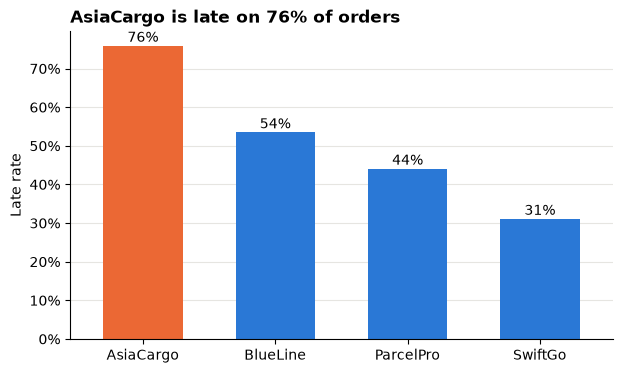

In [40]:
# 13a. BAR – late rate by carrier, sorted, worst carrier highlighted  按承运商的延迟率，排序，最差的强调
late_by_carrier = df.groupby('carrier')['any_late'].mean().sort_values(ascending=False)
colors = [ORANGE if c == late_by_carrier.index[0] else BLUE for c in late_by_carrier.index]

ax = late_by_carrier.plot(kind='bar', color=colors, width=0.6, figsize=(7, 4))
tidy(ax, f'{late_by_carrier.index[0]} is late on {late_by_carrier.iloc[0]:.0%} of orders', 'Late rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
for i, v in enumerate(late_by_carrier):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=10)      # direct labels  直接标数字
plt.show()

📒 Read the code 读代码: `sort_values(ascending=False)` → big to small. The list `colors` gives each bar its own colour — orange only for the first (worst). `ax.text(x, y, text)` writes the number above each bar so nobody needs to read the axis.  
📒 `sort_values(ascending=False)` → 从大到小。`colors` 清单给每根柱子自己的颜色 —— 只有第一根（最差）是橙色。`ax.text(x, y, 文字)` 在每根柱子上面写数字，不用看坐标轴。

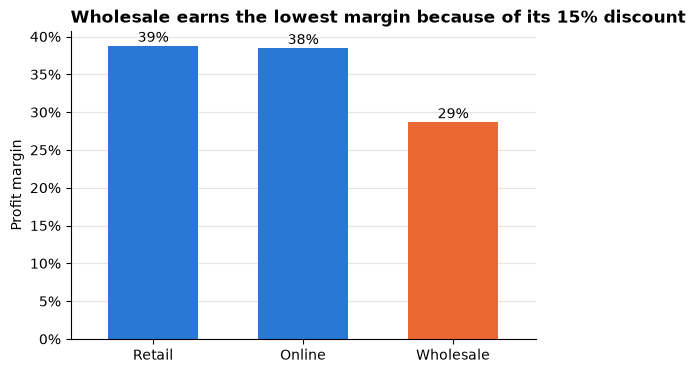

In [42]:
# 13b. BAR – margin % by segment: the "sales ≠ profit" story  各客群利润率："销售 ≠ 利润"的故事
m = seg['margin_pct'].sort_values(ascending=False)
ax = m.plot(kind='bar', color=[BLUE if s != 'Wholesale' else ORANGE for s in m.index], width=0.6, figsize=(6, 4))
tidy(ax, 'Wholesale earns the lowest margin because of its 15% discount', 'Profit margin')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
for i, v in enumerate(m): ax.text(i, v + 0.005, f'{v:.0%}', ha='center')
plt.show()

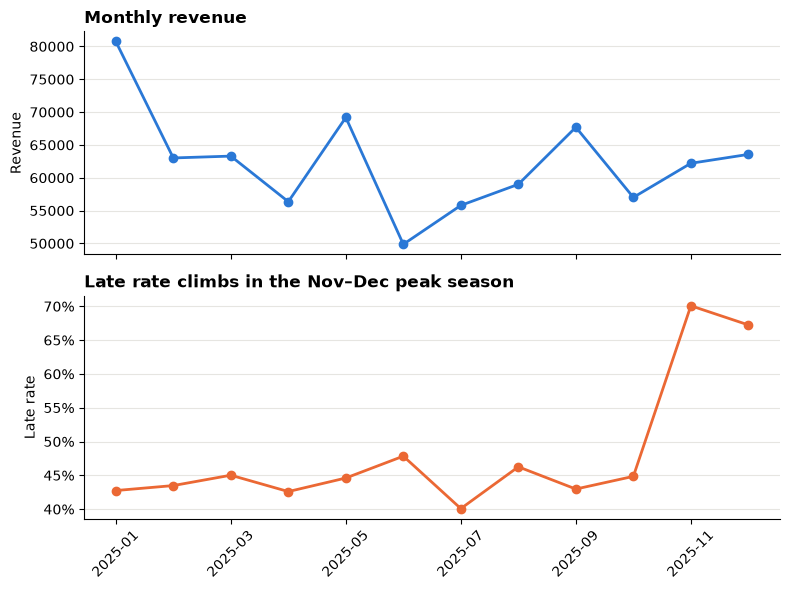

In [43]:
# 13c. LINE – monthly revenue and monthly late rate: TWO charts, not two axes  每月收入和每月延迟率：两张图，不是两个轴
monthly2 = df.groupby('month').agg(revenue=('revenue', 'sum'), late_rate=('any_late', 'mean'))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
monthly2['revenue'].plot(ax=ax1, color=BLUE, linewidth=2, marker='o')
tidy(ax1, 'Monthly revenue', 'Revenue')
monthly2['late_rate'].plot(ax=ax2, color=ORANGE, linewidth=2, marker='o')
tidy(ax2, 'Late rate climbs in the Nov–Dec peak season', 'Late rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

📒 `plt.subplots(2, 1, sharex=True)` = 2 charts stacked, same x-axis (months). This is the honest way to show two measures with different units. A dual-axis chart (revenue on left, % on right) looks clever but readers misjudge the crossing lines — avoid it.  
📒 `plt.subplots(2, 1, sharex=True)` = 上下两张图，共用 x 轴（月份）。这是显示两个单位不同的度量的诚实方法。双 y 轴图（左边收入、右边百分比）看起来聪明，但读者会误判交叉的线 —— 避免用。

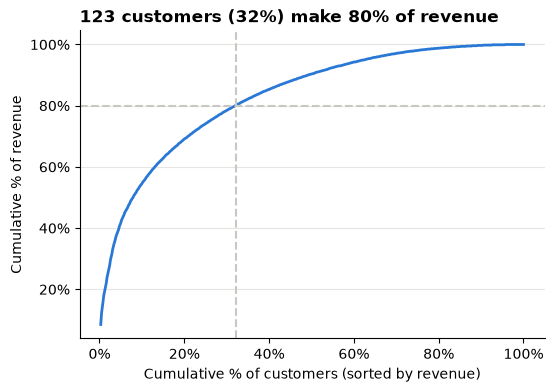

In [44]:
# 13d. LINE – Pareto curve: % of customers vs % of revenue  帕累托曲线：客户占比 vs 收入占比
ax = pareto.set_index('cust_pct')['cum_pct'].plot(color=BLUE, linewidth=2, figsize=(6, 4))
ax.axhline(0.8, color=GREY, linestyle='--'); ax.axvline(n80 / len(pareto), color=GREY, linestyle='--')
tidy(ax, f'{n80} customers ({n80/len(pareto):.0%}) make 80% of revenue', 'Cumulative % of revenue')
ax.set_xlabel('Cumulative % of customers (sorted by revenue)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.show()

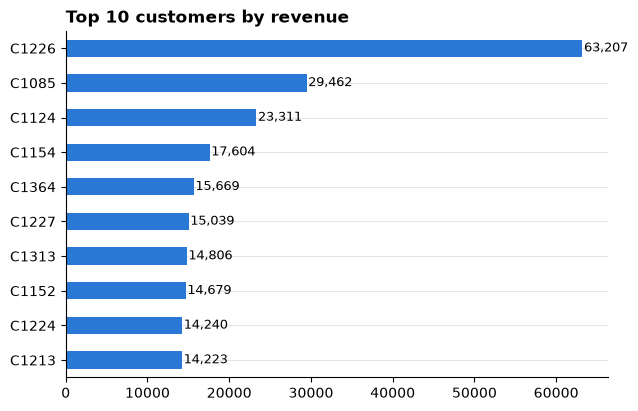

In [45]:
# 13e. Horizontal BAR – top 10 customers by revenue (long labels read better sideways)  前 10 大客户（横向柱状图，长标签更好读）
top10 = cust['revenue'].sort_values(ascending=False).head(10).sort_values()   # sort again so the biggest is on top  再排一次让最大的在最上面
ax = top10.plot(kind='barh', color=BLUE, figsize=(7, 4.5))
tidy(ax, 'Top 10 customers by revenue', '')
for i, v in enumerate(top10): ax.text(v + 200, i, f'{v:,.0f}', va='center', fontsize=9)
plt.show()

✏️ **Your turn 轮到你:** bar chart of **return rate by city**, sorted, highest city in orange. **按城市的退货率**柱状图，排序，最高的城市橙色。

<details><summary>▶️ Answer 答案</summary>

```python
r = df.groupby('city')['is_returned'].mean().sort_values(ascending=False)
ax = r.plot(kind='bar', color=[ORANGE if c == r.index[0] else BLUE for c in r.index], width=0.6, figsize=(7, 4))
tidy(ax, f'{r.index[0]} has the highest return rate', 'Return rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
for i, v in enumerate(r): ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
plt.show()
```
</details>

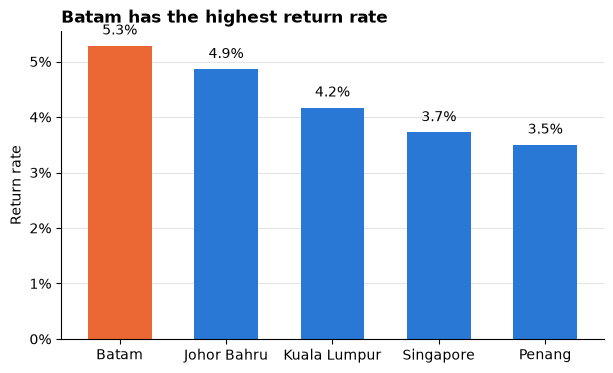

In [46]:
# Write your code here  在这里写代码
r = df.groupby('city')['is_returned'].mean().sort_values(ascending=False)
ax = r.plot(kind='bar', color=[ORANGE if c == r.index[0] else BLUE for c in r.index], width=0.6, figsize=(7, 4))
tidy(ax, f'{r.index[0]} has the highest return rate', 'Return rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
for i, v in enumerate(r): ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
plt.show()

📒 **Save a chart as a picture for your README / LinkedIn 把图存成图片放 README / LinkedIn:** add `plt.savefig('late_rate_by_carrier.png', dpi=150, bbox_inches='tight')` **before** `plt.show()`. 在 `plt.show()` **之前**加 `plt.savefig(...)`。

## ❓ Q&A 问答

<details><summary><b>Q1. Orders 6,000 rows → after joining shipments 6,463 rows. What happened and how to fix? 连接运单后行数从 6,000 变 6,463，怎么回事？怎么修？</b></summary>

One-to-many: some orders have 2 parcels, so each such order appears twice. Fix: `groupby('order_id').agg(...)` on shipments first, then join 1:1. 一对多：有些订单 2 个包裹，每单出现两次。修法：先对运单 `groupby('order_id').agg(...)`，再一对一连接。
</details>

<details><summary><b>Q2. What does `validate='m:1'` do? `validate='m:1'` 做什么？</b></summary>

Checks that the right table's key is unique. If not, pandas raises an error instead of silently doubling rows. 检查右表钥匙唯一。不唯一就报错，而不是悄悄把行翻倍。
</details>

<details><summary><b>Q3. `agg` vs `transform` — output length? 输出长度？</b></summary>

`agg` → one row per group. `transform` → same length as the original table (group value repeated on each row). `agg` → 每组一行。`transform` → 和原表一样长（组的值重复在每一行）。
</details>

<details><summary><b>Q4. Why `max` for delivery days when combining parcels? 合并包裹时为什么天数用 `max`？</b></summary>

The customer has the whole order only when the last parcel arrives. Business logic decides the function. 客户要等最后一个包裹到才算收到整单。业务逻辑决定用哪个函数。
</details>

<details><summary><b>Q5. `cut` vs `qcut`? </b></summary>

`cut` = equal-width value ranges. `qcut` = equal number of rows per bin (quantiles). "Top 20% customers" → `qcut`. `cut` = 值的区间等宽。`qcut` = 每组行数相等（分位数）。"前 20% 客户" → `qcut`。
</details>

<details><summary><b>Q6. Why `nunique('order_id')` instead of `count`? 为什么用 `nunique` 不用 `count`？</b></summary>

If a table can contain the same order twice (after a join), `count` double-counts; `nunique` counts each order once. 如果表里同一订单可能出现两次（连接后），`count` 会重复算；`nunique` 每单只算一次。
</details>

<details><summary><b>Q7. Why keep orders with unknown customer C9999? 为什么保留客户不明的订单 C9999？</b></summary>

The revenue is real. Drop them and total revenue is wrong. Keep them (left join), report them as a data-quality issue. 收入是真的。删掉总收入就错了。保留（左连接），当作数据质量问题报告。
</details>

<details><summary><b>Q8. Why sort before `groupby().cumsum()`? 为什么 `groupby().cumsum()` 之前要排序？</b></summary>

cumsum follows row order. Sort by customer then date, or the running total is meaningless. 累计按行的顺序。先按客户再按日期排序，否则累计没意义。
</details>

## 📋 Summary 总结

| Idea 概念 | Code 代码 | Remember 记住 |
|---|---|---|
| Check keys before join 连接前查钥匙 | `is_unique`, `duplicated()`, `nunique()`, `isin()` | "one" side must be unique "一"那边必须唯一 |
| Safe join 安全连接 | `merge(..., how='left', validate='m:1')` | validate = free insurance 免费保险 |
| Fix duplicates 修重复 | `drop_duplicates(subset=key, keep='first')` | decide the rule, document it 定规则、写下来 |
| One-to-many trap 一对多陷阱 | aggregate the many side first: `groupby(key).agg()` | then join 1:1 再一对一连接 |
| Customer-level table 客户层级表 | `groupby('customer_id').agg(nunique, first, min, max, sum, mean)` | rates need numerator ÷ denominator 比率要分子÷分母 |
| Concentration 集中度 | sort → `cumsum()` → ÷ total | 80/20 |
| Equal-size groups 等份分组 | `pd.qcut(x, 5, labels=...)` | vs `pd.cut` equal width 等宽 |
| Group value on each row 组值贴每行 | `groupby().transform('sum')` | % of total, vs group average 占比、和组平均比 |
| Running total per group 每组累计 | sort → `groupby().cumsum()`, `cumcount()` | |
| Matrix report 矩阵报表 | `pivot_table(index, columns, values, aggfunc={...}, margins=True)` | many values & functions 多值多函数 |
| Custom aggregation 自定义汇总 | `agg(name=('col', lambda s: ...))` | |
| RFM | recency / frequency / monetary → `qcut` scores → label with `apply(axis=1)` | |
